In [14]:
import pandas as pd

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import TruncatedSVD

from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('/mnt/data/public/bgg/games_detailed_info.csv')
df.drop(df.columns[0], axis=1, inplace=True)

/tmp/ipykernel_279/884334997.py:1: DtypeWarning: Columns (29,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/mnt/data/public/bgg/games_detailed_info.csv')


In [3]:
X = df[~df['description'].isna()]['description'][:10000]

In [4]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    stop_words=stopwords.words('english'),
    lowercase=True,
    min_df=5
)

tfidf_vectorizer.fit(X)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(X),
    columns=tfidf_vectorizer.get_feature_names_out(),
)

In [5]:
svd = TruncatedSVD(n_components=df_tfidf.shape[1])
svd.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",13347
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [6]:
energy = svd.singular_values_**2
energy_ratio = energy / energy.sum()
energy_ratio_cumsum = energy_ratio.cumsum()

Explained variance at 3927 SVs: 0.90


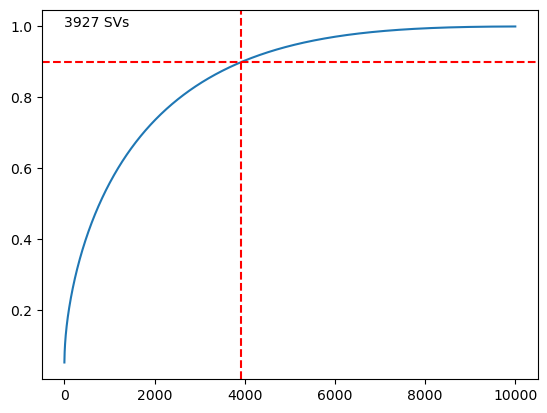

In [7]:
plt.plot([i for i in range(1,len(energy_ratio_cumsum)+1)], energy_ratio_cumsum)
plt.axhline(0.9, color='r', linestyle='--')

thresh = 0
for i in range(len(energy_ratio_cumsum)):
    if energy_ratio_cumsum[i] >= 0.9:
        plt.axvline(i+1, color='r', linestyle='--')
        plt.text(0, 1, f'{i+1} SVs')
        thresh = i+1
        print(f"Explained variance at {i+1} SVs: {energy_ratio_cumsum[i]:.2f}")
        break

In [8]:
W = pd.DataFrame(svd.components_, columns=df_tfidf.columns,
                 index=[f'SV {i+1}' for i in range(df_tfidf.shape[0])])
semantic_vectors = pd.DataFrame(svd.transform(df_tfidf), columns=W.index)
term_topic_matrix = pd.DataFrame(
    svd.components_.T,
    index=df_tfidf.columns,
    columns=[f'SV {i+1}' for i in range(df_tfidf.shape[0])]
)

In [9]:
def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')
    
    return fig, ax

(<Figure size 800x600 with 1 Axes>, <Axes: xlabel='Weight', ylabel='Term'>)

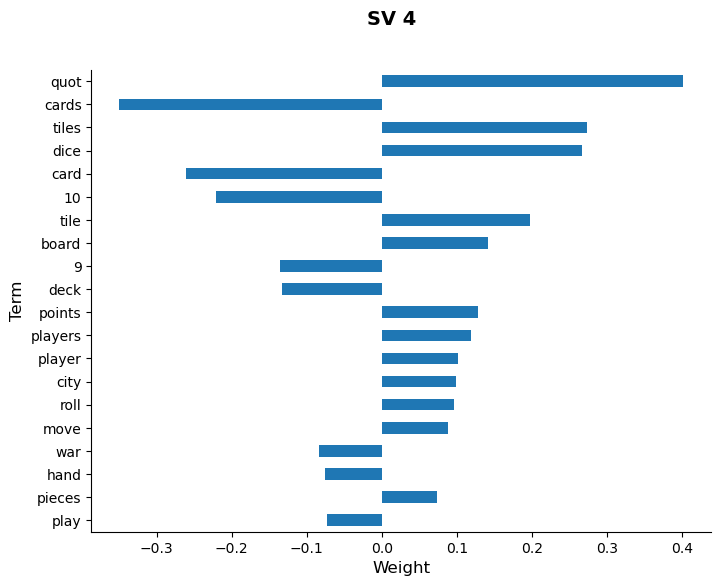

In [13]:
plot_topic_vector(term_topic_matrix, 'SV 4')

In [18]:
from sklearn.cluster import KMeans
import numpy as np

In [16]:
df_transformed = pd.DataFrame(svd.transform(df_tfidf), columns=W.index)
df_trunc = df_transformed.iloc[:, :thresh]

In [19]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Set results container - mean and std of inertias per trial
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(df_trunc)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

Text(0, 0.5, 'Inertia')

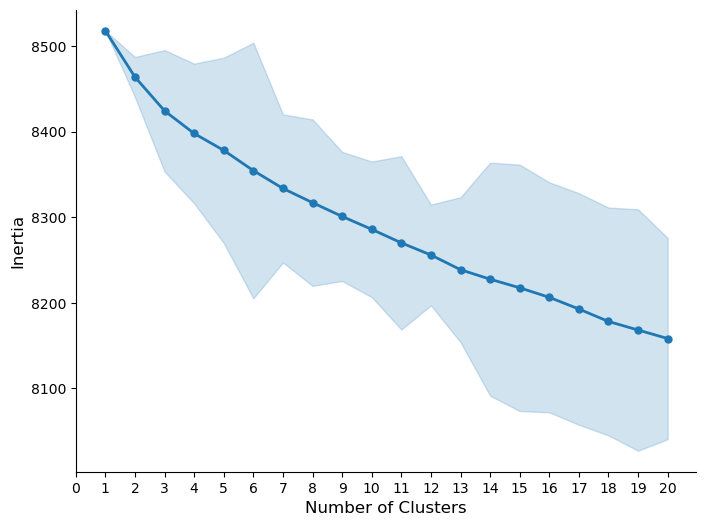

In [20]:
ebar_scale = 10
color='tab:blue'

fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(
    k_range, inertias_mean + ebar_scale*inertias_std,
    inertias_mean - ebar_scale*inertias_std, alpha=0.2, color=color)
ax.plot(k_range, inertias_mean, 'o-', lw=2, ms=5, color=color)
ax.set_xticks(range(0, max(k_range) + 1))

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)